In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv("canada_per_capita_income.csv")

In [ ]:
df.head()

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


In [ ]:
df.shape

(47, 2)

In [ ]:
df.tail()

,year,per capita income (US$)
42,2012,42665.25597
43,2013,42676.46837
44,2014,41039.89360
45,2015,35175.18898
46,2016,34229.19363


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     47 non-null     int64  
 1   per capita income (US$)  47 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 884.0 bytes


In [ ]:
df.describe()

,year,per capita income (US$)
count,47.000000,47.000000
mean,1993.000000,18920.137063
std,13.711309,12034.679438
min,1970.000000,3399.299037
25%,1981.500000,9526.914515
50%,1993.000000,16426.725480
75%,2004.500000,27458.601420
max,2016.000000,42676.468370


In [ ]:
df.isnull().sum()

,0
year,0
per capita income (US$),0


In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='per capita income (US$)', ylabel='Count'>

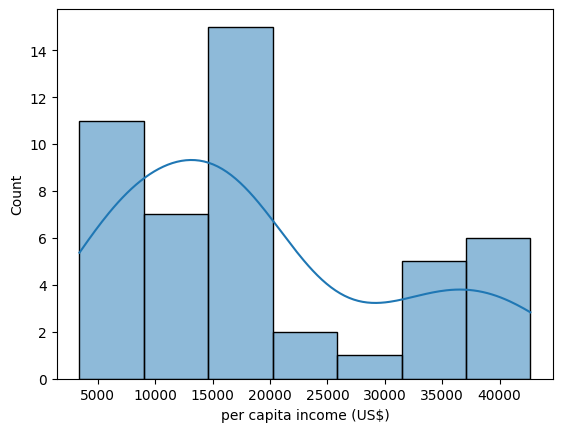

In [ ]:
sns.histplot(df['per capita income (US$)'],kde=True)

In [ ]:
df.columns

Index(['year', 'per capita income (US$)'], dtype='object')

<Axes: >

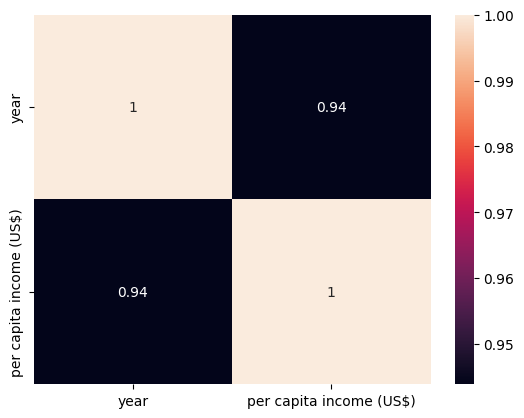

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46],
 [Text(0, 0, '1970'),
  Text(1, 0, '1971'),
  Text(2, 0, '1972'),
  Text(3, 0, '1973'),
  Text(4, 0, '1974'),
  Text(5, 0, '1975'),
  Text(6, 0, '1976'),
  Text(7, 0, '1977'),
  Text(8, 0, '1978'),
  Text(9, 0, '1979'),
  Text(10, 0, '1980'),
  Text(11, 0, '1981'),
  Text(12, 0, '1982'),
  Text(13, 0, '1983'),
  Text(14, 0, '1984'),
  Text(15, 0, '1985'),
  Text(16, 0, '1986'),
  Text(17, 0, '1987'),
  Text(18, 0, '1988'),
  Text(19, 0, '1989'),
  Text(20, 0, '1990'),
  Text(21, 0, '1991'),
  Text(22, 0, '1992'),
  Text(23, 0, '1993'),
  Text(24, 0, '1994'),
  Text(25, 0, '1995'),
  Text(26, 0, '1996'),
  Text(27, 0, '1997'),
  Text(28, 0, '1998'),
  Text(29, 0, '1999'),
  Text(30, 0, '2000'),
  Text(31, 0, '2001'),
 

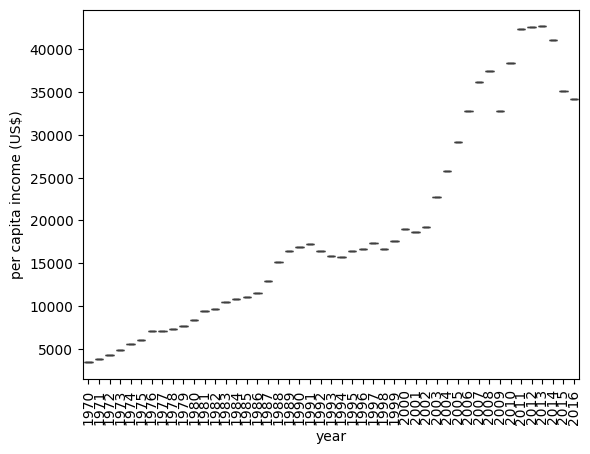

In [ ]:
sns.boxplot(data=df, x='year', y='per capita income (US$)')
plt.xticks(rotation=90)

In [ ]:
X=df.drop('per capita income (US$)', axis=1)
y=df['per capita income (US$)']

In [ ]:
from sklearn.preprocessing import StandardScaler

col=['year' ]  # apply standardization between -3 to 3
scaler=StandardScaler()

X[col]=scaler.fit_transform(X[col])

In [ ]:
X.head()

,year
0,-1.695582
1,-1.621862
2,-1.548141
3,-1.474420
4,-1.400699


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
model=LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
y_pred

array([22279.39968245, 32061.10983855, 21464.25716944, 35321.67989059,
       19833.97214342, 29615.68229953, 10052.26198731, 15758.25957838,
        3531.12188324, 20649.11465643])

In [ ]:
y_test

,per capita income (US$)
27,17310.757750
39,32755.176820
26,16699.826680
43,42676.468370
24,15755.820270
36,32738.262900
12,9619.438377
19,16426.725480
4,5576.514583
25,16369.317250


In [ ]:
r2=r2_score(y_test, y_pred)
r2

0.8751771396846301

In [ ]:
n=X_test.shape[0]
p=X_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
adjusted_r2


0.8595742821452088

The Linear Regression model performed well on the dataset with an R² score of approximately 0.875, which means the model explains about 87.5% of the variance in the target variable. The adjusted R² score is also close to the R² value, indicating that the model is not overfitting and the selected features contribute meaningfully to prediction. The predicted values follow the overall trend of the dataset reasonably well, making the model suitable for basic prediction and trend analysis tasks.